## Trade openness and employment: 
Do EU countries with greater trade openness (total trade — exports plus imports — as a share of GDP) show different unemployment levels?

In [13]:
import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style= "whitegrid")

conn = sqlite3.connect(Path.cwd().parent/"database/ue_market.db")
pd.read_sql("SELECT name FROM sqlite_master WHERE   type= 'table'", conn)

,name
0,trade_category
1,trade_total
2,gdp_ue
3,unemployment_ue
4,data_breaks_ue


In [14]:
df_openness= pd.read_sql(""" 
 WITH CTE_trade_base AS (
    SELECT a.country_code, a.country, a.year, a.gdp_meur,
           b.unemployment_rate, c.value_meur AS trade_value, c.indic_et
    FROM gdp_ue a
    JOIN unemployment_ue b ON a.country_code = b.country_code AND a.year = b.year
    JOIN trade_total c ON a.country_code = c.country_code AND a.year = c.year
    WHERE a.unit = 'nominal' AND c.indic_et IN ('export', 'import')
),
CTE_pivoted AS (
    SELECT country, year, gdp_meur, unemployment_rate,
           MAX(CASE WHEN indic_et = 'export' THEN trade_value END) AS export,
           MAX(CASE WHEN indic_et = 'import' THEN trade_value END) AS import
    FROM CTE_trade_base
    GROUP BY country, year, gdp_meur, unemployment_rate
),
CTE_country_avg AS (
    SELECT country,
           ROUND(AVG((export + import) / gdp_meur * 100), 2) AS avg_openness,
           ROUND(AVG(unemployment_rate), 2) AS avg_unemployment
    FROM CTE_pivoted
    GROUP BY country
)
SELECT
    country,
    avg_openness,
    avg_unemployment,
    CASE 
        WHEN buckets = 1 THEN 'low'
        WHEN buckets = 2 THEN 'medium'
        WHEN buckets = 3 THEN 'high'
    END AS openness_level
FROM (
    SELECT
        country,
        avg_openness,
        avg_unemployment,
        NTILE(3) OVER (ORDER BY avg_openness) AS buckets
    FROM CTE_country_avg
) sub
ORDER BY avg_openness DESC
""", conn)

Trade openness is calculated as (exports + imports) / GDP using nominal values ​​for both, to ensure consistency in the price basis—in accordance with standard practice for measuring trade openness.

In [15]:
df_openness

,country,avg_openness,avg_unemployment,openness_level
0,Slovenia,187.86,4.92,high
1,Belgium,170.37,6.17,high
2,Slovakia,170.28,6.60,high
3,Hungary,151.40,4.06,high
4,Czechia,148.55,2.67,high
5,Netherlands,147.70,4.60,high
6,Lithuania,120.05,7.00,high
7,Estonia,110.48,6.27,high
8,Latvia,108.63,7.50,high
9,Bulgaria,101.63,5.47,medium


In [16]:
df_openness.groupby("openness_level").agg({"country": "count", "avg_openness": "mean", "avg_unemployment": ["mean", "median"]}).reset_index().round(2)

openness_level country avg_openness avg_unemployment       
                   count         mean             mean median
0           high       9       146.15             5.53   6.17
1            low       9        53.58             8.69   7.94
2         medium       9        75.79             5.80   5.58

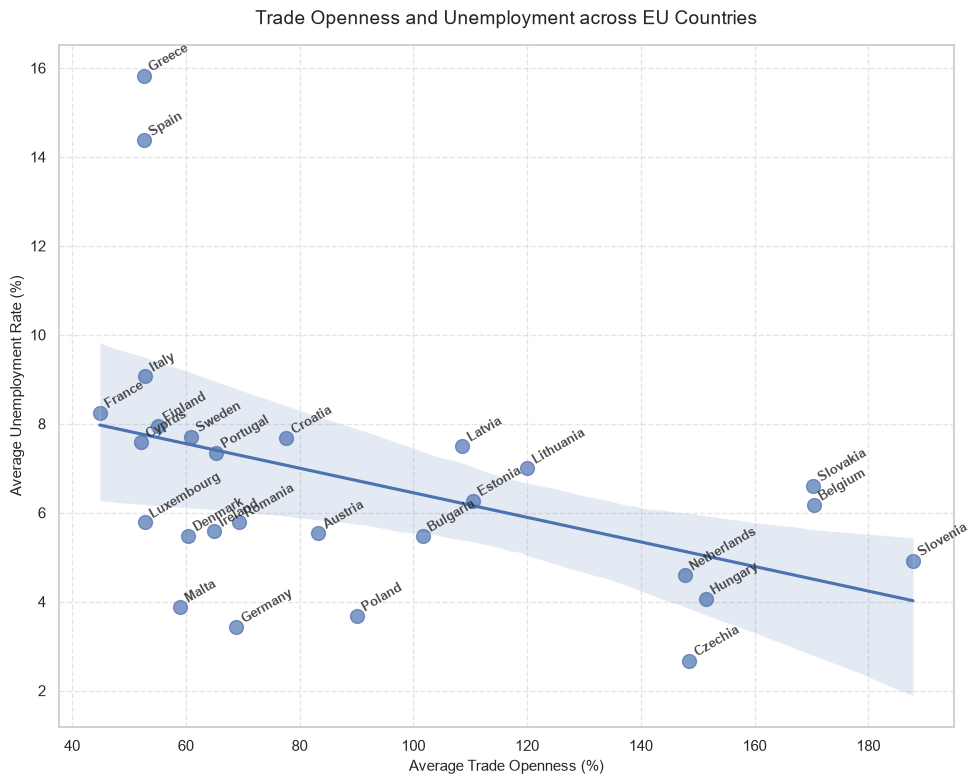

In [17]:
df_plot = df_openness.reset_index()
plt.figure(figsize=(10, 8))
sns.regplot(
    data=df_plot,
    x="avg_openness",
    y="avg_unemployment",
    color="#4c72b0",
    scatter_kws={"s": 100, "alpha": 0.7}
)

for index, row in df_plot.iterrows():
    plt.text(
        x=row["avg_openness"] + 0.5,      
        y=row["avg_unemployment"] + 0.1, 
        s=row["country"],
        fontsize=9,
        weight="bold",
        alpha=0.8,
        rotation=30
    )

plt.title("Trade Openness and Unemployment across EU Countries", fontsize=14, pad=15)
plt.xlabel("Average Trade Openness (%)", fontsize=11)
plt.ylabel("Average Unemployment Rate (%)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(Path.cwd().parent/"data/charts/trade_openness_unemployment.png", dpi=150, bbox_inches="tight")
plt.show()

As a robustness check, I also calculated the correlation using "real" GDP, which accounts for inflation.
The level of correlation is very close to that of the nominal figure.

In [18]:
df_openness_real= pd.read_sql(""" 
 WITH CTE_trade_base AS (
    SELECT a.country_code, a.country, a.year, a.gdp_meur,
           b.unemployment_rate, c.value_meur AS trade_value, c.indic_et
    FROM gdp_ue a
    JOIN unemployment_ue b ON a.country_code = b.country_code AND a.year = b.year
    JOIN trade_total c ON a.country_code = c.country_code AND a.year = c.year
    WHERE a.unit = 'real' AND c.indic_et IN ('export', 'import')
),
CTE_pivoted AS (
    SELECT country, year, gdp_meur, unemployment_rate,
           MAX(CASE WHEN indic_et = 'export' THEN trade_value END) AS export,
           MAX(CASE WHEN indic_et = 'import' THEN trade_value END) AS import
    FROM CTE_trade_base
    GROUP BY country, year, gdp_meur, unemployment_rate
),
CTE_country_avg AS (
    SELECT country,
           ROUND(AVG((export + import) / gdp_meur * 100), 2) AS avg_openness,
           ROUND(AVG(unemployment_rate), 2) AS avg_unemployment
    FROM CTE_pivoted
    GROUP BY country
)
SELECT
    country,
    avg_openness,
    avg_unemployment,
    CASE 
        WHEN buckets = 1 THEN 'low'
        WHEN buckets = 2 THEN 'medium'
        WHEN buckets = 3 THEN 'high'
    END AS openness_level
FROM (
    SELECT
        country,
        avg_openness,
        avg_unemployment,
        NTILE(3) OVER (ORDER BY avg_openness) AS buckets
    FROM CTE_country_avg
) sub
ORDER BY avg_openness DESC
""", conn)

corr_nominal = df_openness["avg_openness"].corr(df_openness["avg_unemployment"])
corr_real = df_openness_real["avg_openness"].corr(df_openness_real["avg_unemployment"])
print(f"Openness vs unemployment: {corr_nominal:.2f} (nominal GDP), {corr_real:.2f} (real GDP)")

Openness vs unemployment: -0.41 (nominal GDP), -0.45 (real GDP)


### Conclusions for Trade openness and unemployment rate

A moderate negative correlation (r ≈ -0.41) emerges between trade openness and unemployment: more open countries tend to have lower unemployment (median 6.2% in the high-openness group versus 7.9% in the low-openness group). This result is robust to the GDP definition: the correlation is -0.41 with nominal GDP and -0.45 with real GDP. <br>
However, the relationship is weak and highly dispersed: openness explains only part of the variability. It is also likely confounded by country size and geography: highly open countries are predominantly small Eastern European economies, while those with low openness are large Mediterranean economies, where high unemployment stems from structural causes largely unrelated to trade. Correlation therefore does not imply causation.